## ECON 470 Hw

In [1]:
library(tidyverse)
library(stringr)
library(readr)
library(fs)
library(ggplot2)
library(dplyr)
library(broom)
library(tidyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
options(repos = c(CRAN = "https://cloud.r-project.org"))

if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, data.table)

install.packages("knitr", lib="~/R/x86_64-conda-linux-gnu-library/4.3")
install.packages("rmarkdown", lib="~/R/x86_64-conda-linux-gnu-library/4.3")
install.packages("kableExtra")

Loading required package: pacman

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [3]:
data.2010 <- read_csv("..//data/data-2010.csv")
data.2011 <- read_csv("..//data/data-2011.csv")
data.2012 <- read_csv("..//data/data-2012.csv")
data.2013 <- read_csv("..//data/data-2013.csv")
data.2014 <- read_csv("..//data/data-2014.csv")
data.2015 <- read_csv("..//data/data-2015.csv")

Rows: 108222 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (66): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl (10): partcd_score, risk_star5, risk_star45, risk_star4, risk_star35, ri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68003 Columns: 95
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (71): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl  (9): risk_star5, risk_star45, risk_star4, risk_star35, risk_star3, risk...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types =

In [4]:
fix_type <- function(df) {
  df$org_parent <- as.character(df$org_parent)
  df
}

data.2011 <- fix_type(data.2011)

In [5]:
combined <- bind_rows(
  data.2010,
  data.2011,
  data.2012,
  data.2013,
  data.2014,
  data.2015
) %>%
  mutate(mkt_share = avg_enrollment / avg_enrolled)

In [6]:
colnames(combined)

[1] "contractid"          "planid"              "fips"               
  [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
  [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
 [10] "last_enrollment"     "state"               "county"             
 [13] "org_type"            "plan_type"           "partd"              
 [16] "snp"                 "eghp"                "org_name"           
 [19] "org_marketing_name"  "plan_name"           "parent_org"         
 [22] "contract_date"       "state_long"          "county_long"        
 [25] "n_elig"              "n_enrol"             "avg_eligibles"      
 [28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
 [31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
 [34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
 [37] "first_enrolled"      "last_enrolled"       "ssa"                
 [40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
 [43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
 [46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
 [49] "mental_health"       "osteo_test"          "physical_monitor"   
 [52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
 [55] "bloodpressure"       "ra_manage"           "copd_test"          
 [58] "bladder"             "falling"             "nodelays"           
 [61] "doctor_communicate"  "carequickly"         "customer_service"   
 [64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
 [67] "appeals_timely"      "appeals_review"      "leave_plan"         
 [70] "audit_problems"      "hold_times"          "info_accuracy"      
 [73] "ttyt_available"      "new_contract"        "partc_score"        
 [76] "partcd_score"        "Star_Rating"         "aged_parta"         
 [79] "aged_partb"          "risk_ab"             "risk_star5"         
 [82] "risk_star45"         "risk_star4"          "risk_star35"        
 [85] "risk_star3"          "risk_star25"         "risk_bonus5"        
 [88] "risk_bonus35"        "risk_bonus0"         "year"               
 [91] "ma_rate"             "org_parent"          "cv_cholscreen"      
 [94] "diab_cholscreen"     "bmi_assess"          "specialneeds_manage"
 [97] "older_medication"    "older_function"      "older_pain"         
[100] "diabetes_eye"        "diabetes_kidney"     "diabetes_bloodsugar"
[103] "diabetes_chol"       "readmissions"        "coordination"       
[106] "improve"             "X39"                 "X40"                
[109] "low_score"           "X41"                 "X42"                
[112] "access_problems"     "mkt_share"

# Problem 1

In [7]:
summary_table <- combined %>%
  group_by(year) %>%
  summarise(
    `Mean Star Rating` = round(mean(Star_Rating, na.rm = TRUE), 2),
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_table)

# A tibble: 6 × 5
   year `Mean Star Rating` `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>              <dbl>               <dbl>         <int>
1  2010               2.97               256.              0.0658        108222
2  2011               3.26               343.              0.0855         68003
3  2012               3.36               377.              0.0856         67246
4  2013               3.55               396.              0.0815         67835
5  2014               3.81               437.              0.08           62344
6  2015               3.96               470.              0.0787         65499


In [8]:
knitr::kable(summary_table, 
             caption = "Summary Statistics by Year",
             col.names = c("Year", "Mean Star Rating", "Mean Enrollments", "Mean Market Share", "Total Plans"),
             align = c("c","c","c","c","c"), 
             booktabs = TRUE)



Table: Summary Statistics by Year

| Year | Mean Star Rating | Mean Enrollments | Mean Market Share | Total Plans |
|:----:|:----------------:|:----------------:|:-----------------:|:-----------:|
| 2010 |       2.97       |      256.35      |      0.0658       |   108222    |
| 2011 |       3.26       |      343.36      |      0.0855       |    68003    |
| 2012 |       3.36       |      377.34      |      0.0856       |    67246    |
| 2013 |       3.55       |      395.52      |      0.0815       |    67835    |
| 2014 |       3.81       |      436.64      |      0.0800       |    62344    |
| 2015 |       3.96       |      469.68      |      0.0787       |    65499    |

# Problem 2

In [9]:
summary_no_rating <- combined %>%
  filter(is.na(Star_Rating)) %>%
  group_by(year) %>%
  summarise(
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_no_rating)

# A tibble: 6 × 4
   year `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>               <dbl>         <int>
1  2010               107.              0.0673         48643
2  2011               168.              0.09           12754
3  2012               173.              0.0567          9077
4  2013               214.              0.06            3661
5  2014               258.              0.0557          3708
6  2015               314.              0.0405          4680


In [10]:
knitr::kable(summary_no_rating, 
             caption = "Summary Statistics for Plans Without Star Ratings",
             col.names = c("Year", "Mean Enrollments", "Mean Market Share", "Total Plans"),
             align = c("c","c","c","c"), 
             booktabs = TRUE)



Table: Summary Statistics for Plans Without Star Ratings

| Year | Mean Enrollments | Mean Market Share | Total Plans |
|:----:|:----------------:|:-----------------:|:-----------:|
| 2010 |      107.34      |      0.0673       |    48643    |
| 2011 |      167.90      |      0.0900       |    12754    |
| 2012 |      172.73      |      0.0567       |    9077     |
| 2013 |      213.50      |      0.0600       |    3661     |
| 2014 |      257.60      |      0.0557       |    3708     |
| 2015 |      314.21      |      0.0405       |    4680     |

# Problem 3

We can observe a spike in 2.5 star ratings in 2010 and a relatively more bell shaped distribution of star ratings for 2012 and 2015. 

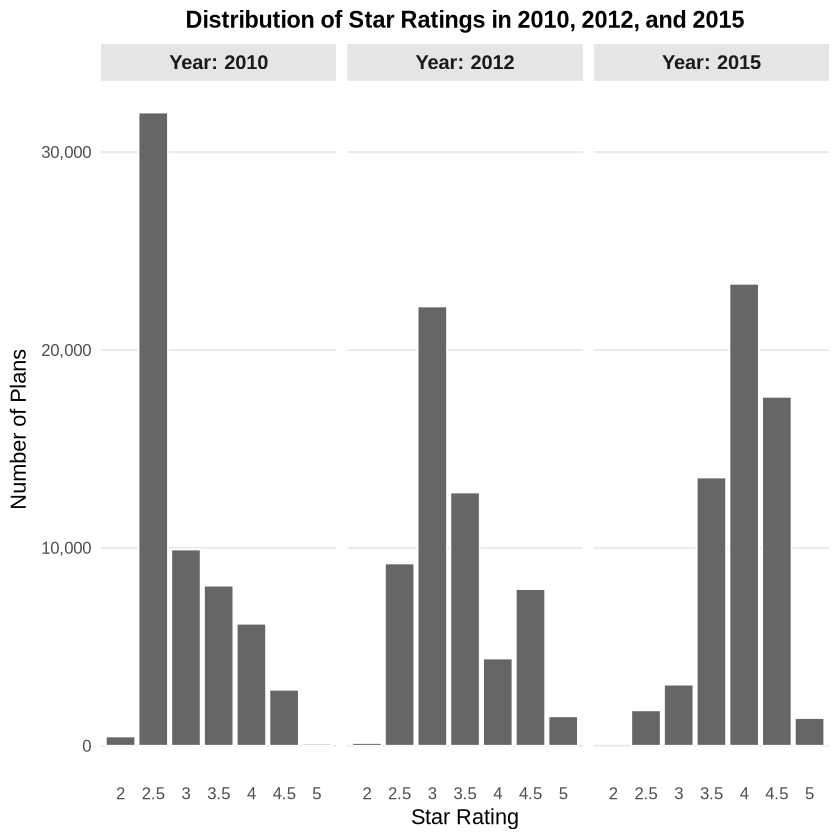

In [11]:
combined %>%
  filter(year %in% c(2010, 2012, 2015), !is.na(Star_Rating)) %>%
  mutate(year = factor(year, labels = c("Year: 2010", "Year: 2012", "Year: 2015"))) %>%
  ggplot(aes(x = as.factor(Star_Rating))) +
  geom_bar(fill = "gray40", color = "white") +
  facet_wrap(~ year, labeller = label_value) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Distribution of Star Ratings in 2010, 2012, and 2015",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title       = element_text(hjust = 0.5, face = "bold", size = 14),
    strip.text       = element_text(face = "bold", size = 12),
    strip.background = element_rect(fill = "gray90", color = NA),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    axis.text        = element_text(size = 10)
  )

# Problem 4

In [12]:
combined <- combined %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating== 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45  = as.integer(Star_Rating >= 4.5)
  )

results_list <- list()

for(yr in 2010:2015){
  cat("\nYear:", yr, "\n")
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(Star_Rating), !is.na(mkt_share)))
  print(summary(ols))
}



Year: 2010 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr, !is.na(Star_Rating), 
        !is.na(mkt_share)))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.07593 -0.05415 -0.03449  0.01530  0.72831 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0633531  0.0009855  64.288  < 2e-16 ***
star_3       0.0126028  0.0018242   6.908 5.05e-12 ***
star_35      0.0005280  0.0018955   0.279  0.78059    
star_4      -0.0036213  0.0021302  -1.700  0.08916 .  
star_45     -0.0075592  0.0026960  -2.804  0.00505 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.09138 on 18988 degrees of freedom
Multiple R-squared:  0.003954,	Adjusted R-squared:  0.003744 
F-statistic: 18.84 on 4 and 18988 DF,  p-value: 1.788e-15


Year: 2011 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr,

In [13]:
results_list <- list()

for(yr in 2010:2015){
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(partc_score), !is.na(mkt_share)))
  results_list[[as.character(yr)]] <- coef(ols)
}

ols_table <- as.data.frame(results_list)
colnames(ols_table) <- c("2010", "2011", "2012", "2013", "2014", "2015")
rownames(ols_table) <- c("Intercept (≤2.5 stars)", "3 Stars", "3.5 Stars", "4 Stars", "4.5+ Stars")

print(round(ols_table, 4))

                          2010    2011    2012   2013   2014   2015
Intercept (≤2.5 stars)  0.0634  0.0702  0.0789 0.0491 0.0640 0.0606
3 Stars                 0.0126  0.0350  0.0307 0.0621 0.0276 0.0271
3.5 Stars               0.0005  0.0191  0.0129 0.0385 0.0274 0.0388
4 Stars                -0.0036  0.0028 -0.0246 0.0172 0.0074 0.0115
4.5+ Stars             -0.0076 -0.0095 -0.0134 0.0222 0.0071 0.0233


In [14]:
knitr::kable(round(ols_table, 4), 
             caption = "OLS Estimates of Star Rating Effects on Market Share",
             col.names = c("2010", "2011", "2012", "2013", "2014", "2015"),
             booktabs = TRUE)



Table: OLS Estimates of Star Rating Effects on Market Share

|                       |    2010|    2011|    2012|   2013|   2014|   2015|
|:----------------------|-------:|-------:|-------:|------:|------:|------:|
|Intercept (≤2.5 stars) |  0.0634|  0.0702|  0.0789| 0.0491| 0.0640| 0.0606|
|3 Stars                |  0.0126|  0.0350|  0.0307| 0.0621| 0.0276| 0.0271|
|3.5 Stars              |  0.0005|  0.0191|  0.0129| 0.0385| 0.0274| 0.0388|
|4 Stars                | -0.0036|  0.0028| -0.0246| 0.0172| 0.0074| 0.0115|
|4.5+ Stars             | -0.0076| -0.0095| -0.0134| 0.0222| 0.0071| 0.0233|

# Problem 5

In [15]:
quality_vars <- c(
  "breastcancer_screen",
  "rectalcancer_screen",
  "cv_diab_cholscreen",
  "glaucoma_test",
  "monitoring",
  "flu_vaccine",
  "pn_vaccine",
  "physical_health",
  "mental_health",
  "osteo_test",
  "physical_monitor",
  "primaryaccess",
  "osteo_manage",
  "diab_healthy",
  "bloodpressure",
  "ra_manage",
  "copd_test",
  "bladder",
  "falling",
  "nodelays",
  "doctor_communicate",
  "carequickly",
  "customer_service",
  "overallrating_care",
  "overallrating_plan",
  "complaints_plan",
  "appeals_timely",
  "appeals_review",
  "leave_plan",
  "audit_problems",
  "hold_times",
  "info_accuracy",
  "ttyt_available"
)

datanew.2010 <- data.2010 %>%
  filter(!is.na(avg_enrollment)) %>%
  mutate(
    mkt_share = avg_enrollment / avg_enrolled) %>%
  rowwise() %>%
  mutate(
    raw_rating = mean(c_across(all_of(quality_vars)), na.rm = TRUE)
  ) %>%
  ungroup()

In [16]:
round_up_counts <- datanew.2010 %>%
  #distinct(contractid, fips, .keep_all = TRUE) %>%
  filter(!is.na(raw_rating)) %>%
  filter(!is.na(partc_score)) %>%
  mutate(
    round_ups = ifelse(raw_rating >= 2.75 & raw_rating < 3.00 & partc_score == 3.0, "Rounded up to 3",
               ifelse(raw_rating >= 3.25 & raw_rating < 3.5 & partc_score == 3.5, "Rounded up to 3.5",
               ifelse(raw_rating >= 3.75 & raw_rating < 4.0 & partc_score == 4.0, "Rounded up to 4",
               ifelse(raw_rating >= 4.25 & raw_rating < 4.5 & partc_score == 4.5, "Rounded up to 4.5",
               ifelse(raw_rating >= 4.75 & partc_score == 5.0, "Rounded up to 5",
               NA)))))
  ) %>%
  filter(!is.na(round_ups)) %>%
  count(round_ups) %>%
  rename('Star Rating' = round_ups, 'Number Of Plans' = n)

print(round_up_counts)

# A tibble: 5 × 2
  `Star Rating`     `Number Of Plans`
  <chr>                         <int>
1 Rounded up to 3                1672
2 Rounded up to 3.5              1762
3 Rounded up to 4                1594
4 Rounded up to 4.5               193
5 Rounded up to 5                  29


In [17]:
knitr::kable(round_up_counts, 
             caption = "Plans Rounded Up to Each Star Rating (2010)",
             col.names = c("Star Rating", "Number of Plans"),
             align = c("l","c"), 
             booktabs = TRUE)



Table: Plans Rounded Up to Each Star Rating (2010)

|Star Rating       | Number of Plans |
|:-----------------|:---------------:|
|Rounded up to 3   |      1672       |
|Rounded up to 3.5 |      1762       |
|Rounded up to 4   |      1594       |
|Rounded up to 4.5 |       193       |
|Rounded up to 5   |       29        |

# Problem 6

In [18]:
run_rd_ols <- function(data, cutoff, stars_below, stars_above) {
  data %>%
    filter(!is.na(raw_rating), !is.na(partc_score),
           partc_score %in% c(stars_below, stars_above)) %>%
    mutate(
      score = raw_rating - cutoff,
      treat = as.integer(score >= 0),
      score_treat = score * treat
    ) %>%
    filter(score >= -0.125, score <= 0.125) %>%
    lm(mkt_share ~ score + treat + score_treat, data = .)
}

star3  <- run_rd_ols(datanew.2010, cutoff = 2.75, stars_below = 2.5, stars_above = 3.0)
star3.5 <- run_rd_ols(datanew.2010, cutoff = 3.25, stars_below = 3.0, stars_above = 3.5)

rename_coefs <- function(mod) {
  s <- summary(mod)
  rownames(s$coefficients) <- c("Intercept", "Running Score", "Rounded", "Running Score x Treat")
  print(s)
}

rename_coefs(star3)
rename_coefs(star3.5)

print (star3)
print (star3.5)


Call:
lm(formula = mkt_share ~ score + treat + score_treat, data = .)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.10400 -0.05003 -0.02918  0.01766  0.69606 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
Intercept              0.016286   0.003355   4.855 1.24e-06 ***
Running Score         -0.740276   0.041505 -17.836  < 2e-16 ***
Rounded                0.054601   0.008311   6.570 5.53e-11 ***
Running Score x Treat  0.957978   0.108914   8.796  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0955 on 5305 degrees of freedom
Multiple R-squared:  0.05949,	Adjusted R-squared:  0.05895 
F-statistic: 111.8 on 3 and 5305 DF,  p-value: < 2.2e-16


Call:
lm(formula = mkt_share ~ score + treat + score_treat, data = .)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.09911 -0.05284 -0.03313  0.01388  0.63867 

Coefficients:
                       Estimate Std. Error t value Pr(>

In [19]:
results_table <- data.frame(
  Statistic   = c("Intercept", "Rounded", "Running Score", "Num.Obs.", "R2"),
  `3 Stars`   = c(
    round(coef(star3)["(Intercept)"], 3),
    round(coef(star3)["treat"],       3),
    round(coef(star3)["score"],       3),
    nobs(star3),
    round(summary(star3)$r.squared,   3)
  ),
  `3.5 Stars` = c(
    round(coef(star3.5)["(Intercept)"], 3),
    round(coef(star3.5)["treat"],       3),
    round(coef(star3.5)["score"],       3),
    nobs(star3.5),
    round(summary(star3.5)$r.squared,   3)
  ),
  check.names = FALSE
)

knitr::kable(
  results_table,
  caption   = "RD Estimates by Star Ratings",
  col.names = c("Statistic", "3 Stars", "3.5 Stars"),
  align     = c("l", "c", "c"),
  booktabs  = TRUE,
  row.names = FALSE
)



Table: RD Estimates by Star Ratings

|Statistic     | 3 Stars  | 3.5 Stars |
|:-------------|:--------:|:---------:|
|Intercept     |  0.016   |   0.102   |
|Rounded       |  0.055   |  -0.040   |
|Running Score |  -0.740  |   0.417   |
|Num.Obs.      | 5309.000 | 1882.000  |
|R2            |  0.059   |   0.015   |

# Problem 7

In [20]:
install.packages("rdrobust")
library(rdrobust)

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


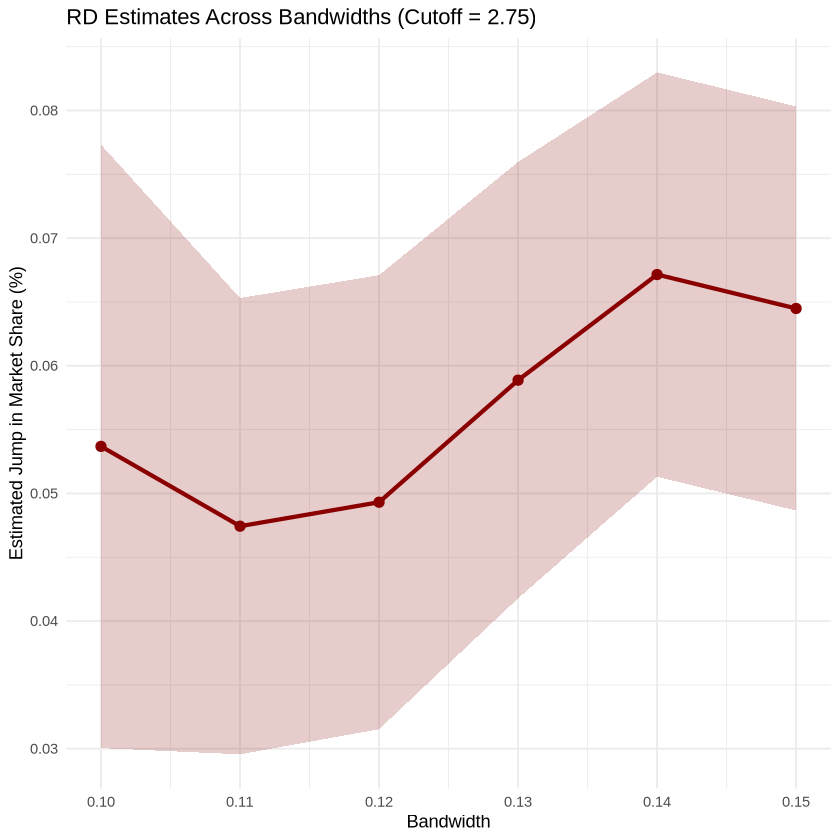

In [21]:
rd1 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3.0),
    raw_rating >= 2.5,
    raw_rating <= 3.0,
    (raw_rating >= 2.75 & Star_Rating == 3.0) | (raw_rating < 2.75 & Star_Rating == 2.5)
  ) %>%
  mutate(score = raw_rating - 2.75) 

est0.1 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.10, p = 1, kernel = "uniform", vce = "hc0")
est0.11 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.11, p = 1, kernel = "uniform", vce = "hc0")
est0.12 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.12, p = 1, kernel = "uniform", vce = "hc0")
est0.13 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.13, p = 1, kernel = "uniform", vce = "hc0")
est0.14 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.14, p = 1, kernel = "uniform", vce = "hc0")
est0.15 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.15, p = 1, kernel = "uniform", vce = "hc0")

results_table_275 <- tibble(
  Bandwidth = c(0.10, 0.11, 0.12, 0.13, 0.14, 0.15),
  Estimate = c(
    est0.1$coef[1], est0.11$coef[1], est0.12$coef[1],
    est0.13$coef[1], est0.14$coef[1], est0.15$coef[1]
  ),
  CI_lower = c(
    est0.1$coef[1]  - 1.96 * est0.1$se[1],
    est0.11$coef[1] - 1.96 * est0.11$se[1],
    est0.12$coef[1] - 1.96 * est0.12$se[1],
    est0.13$coef[1] - 1.96 * est0.13$se[1],
    est0.14$coef[1] - 1.96 * est0.14$se[1],
    est0.15$coef[1] - 1.96 * est0.15$se[1]
  ),
  CI_upper = c(
    est0.1$coef[1]  + 1.96 * est0.1$se[1],
    est0.11$coef[1] + 1.96 * est0.11$se[1],
    est0.12$coef[1] + 1.96 * est0.12$se[1],
    est0.13$coef[1] + 1.96 * est0.13$se[1],
    est0.14$coef[1] + 1.96 * est0.14$se[1],
    est0.15$coef[1] + 1.96 * est0.15$se[1]
  )
)

ggplot(results_table_275, aes(x = Bandwidth, y = Estimate)) +
  geom_line(size = 1.2, color = "darkred") +
  geom_point(size = 2.5, color = "darkred") +
  geom_ribbon(aes(ymin = CI_lower, ymax = CI_upper), alpha = 0.2, fill = "darkred") +
  scale_y_continuous(breaks = seq(0.00, 0.10, by = 0.01)) +
  labs(
    title = "RD Estimates Across Bandwidths (Cutoff = 2.75)",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share (%)"
  ) +
  theme_minimal()

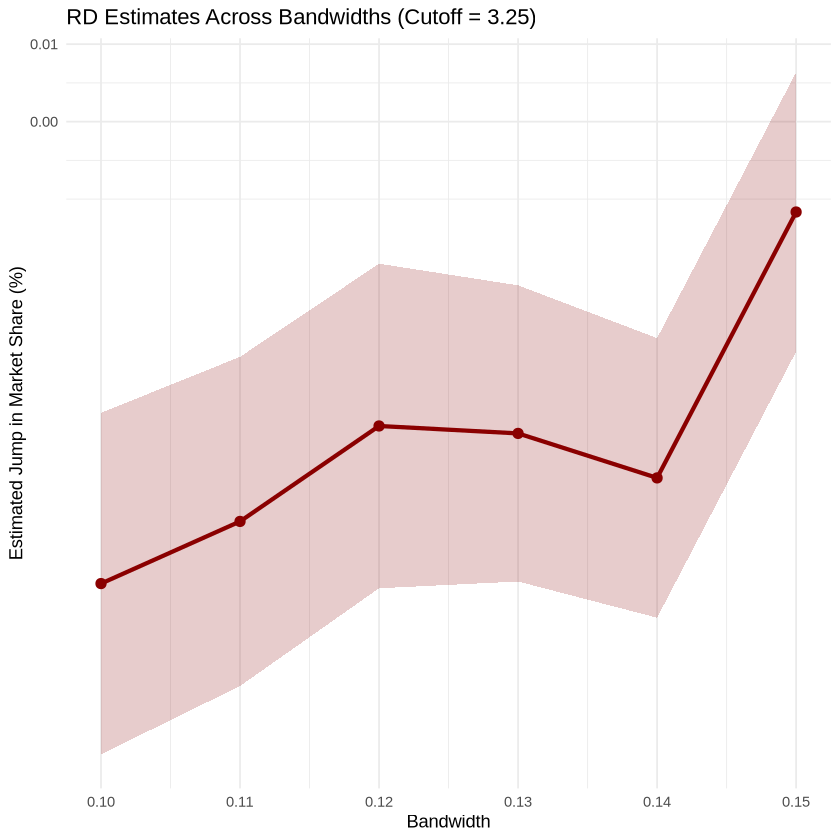

In [22]:
rd2 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3.0, 3.5),
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating >= 3.25 & Star_Rating == 3.5) | (raw_rating < 3.25 & Star_Rating == 3)
  ) %>%
  mutate(score = raw_rating - 3.25) 

est3 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.10, p = 1, kernel = "uniform", vce = "hc0")
est4 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.11, p = 1, kernel = "uniform", vce = "hc0")
est5 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.12, p = 1, kernel = "uniform", vce = "hc0")
est6 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.13, p = 1, kernel = "uniform", vce = "hc0")
est7 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.14, p = 1, kernel = "uniform", vce = "hc0")
est8 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.15, p = 1, kernel = "uniform", vce = "hc0")

results_table_325 <- tibble(
  Bandwidth = c(0.10, 0.11, 0.12, 0.13, 0.14, 0.15),
  Estimate = c(
    est3$coef[1], est4$coef[1], est5$coef[1],
    est6$coef[1], est7$coef[1], est8$coef[1]
  ),
  CI_lower = c(
    est3$coef[1] - 1.96 * est3$se[1],
    est4$coef[1] - 1.96 * est4$se[1],
    est5$coef[1] - 1.96 * est5$se[1],
    est6$coef[1] - 1.96 * est6$se[1],
    est7$coef[1] - 1.96 * est7$se[1],
    est8$coef[1] - 1.96 * est8$se[1]
  ),
  CI_upper = c(
    est3$coef[1] + 1.96 * est3$se[1],
    est4$coef[1] + 1.96 * est4$se[1],
    est5$coef[1] + 1.96 * est5$se[1],
    est6$coef[1] + 1.96 * est6$se[1],
    est7$coef[1] + 1.96 * est7$se[1],
    est8$coef[1] + 1.96 * est8$se[1]
  )
)

ggplot(results_table_325, aes(x = Bandwidth, y = Estimate)) +
  geom_line(size = 1.2, color = "darkred") +
  geom_point(size = 2.5, color = "darkred") +
  geom_ribbon(aes(ymin = CI_lower, ymax = CI_upper), alpha = 0.2, fill = "darkred") +
  scale_y_continuous(breaks = seq(0.00, 0.10, by = 0.01)) +
  labs(
    title = "RD Estimates Across Bandwidths (Cutoff = 3.25)",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share (%)"
  ) +
  theme_minimal()

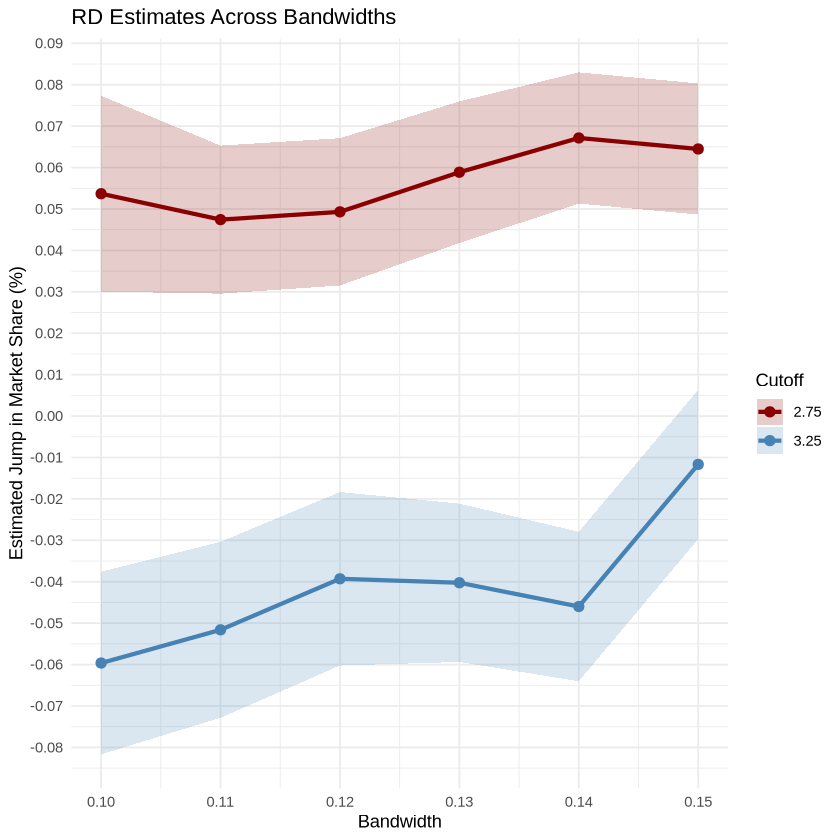

In [23]:
results_combined <- bind_rows(
  results_table_275 %>% mutate(Cutoff = "2.75"),
  results_table_325 %>% mutate(Cutoff = "3.25")
)

ggplot(results_combined, aes(x = Bandwidth, y = Estimate, color = Cutoff, fill = Cutoff)) +
  geom_line(size = 1.2) +
  geom_point(size = 2.5) +
  geom_ribbon(aes(ymin = CI_lower, ymax = CI_upper), alpha = 0.2, color = NA) +
  scale_color_manual(values = c("2.75" = "darkred", "3.25" = "steelblue")) +
  scale_fill_manual(values = c("2.75" = "darkred", "3.25" = "steelblue")) +
  scale_y_continuous(breaks = seq(-0.10, 0.10, by = 0.01)) +  labs(
    title = "RD Estimates Across Bandwidths",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share (%)",
    color = "Cutoff",
    fill = "Cutoff"
  ) +
  theme_minimal()


# Problem 8

At the 2.75 cutoff, the density of the plans spike below the cutoff around 2.65 or -0.10 below the cutoff, showing that many contracts cluster below the threshold. However, when you look at the slope, it is downward, and market share decreases as the plan star rating is closer to the threshold. This suggests that contracts may be manipulating their scores to land below or just above the threshold. The 3 vs 3.5 star cutoff looks more balanced on both sides, with both sides having relatively flat or slightly positive slopes. 

`geom_smooth()` using formula = 'y ~ x'


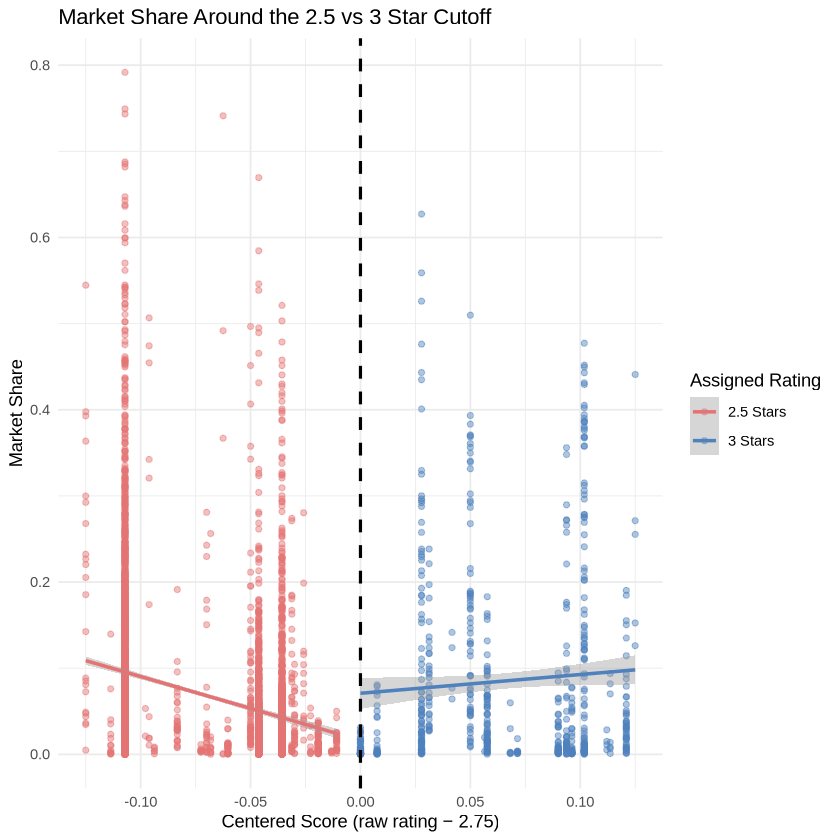

In [24]:
plans_3 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

band_3 <- plans_3 %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating < 2.75  & Star_Rating == 2.5) |
    (raw_rating >= 2.75 & Star_Rating == 3)
  )

rd_3 <- band_3 %>%
  mutate(
    score = raw_rating - 2.75,          
    treat_group = score >= 0,           
    in_window = between(score, -0.125, 0.125),
    interaction = score * treat_group
  )

p_3 <- ggplot(rd_3 %>% filter(in_window),
             aes(x = score, y = mkt_share, color = treat_group)) +
  geom_point(alpha = 0.45, size = 1.4) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 0.9) +
  scale_color_manual(
    values = c("FALSE" = "#E57373", "TRUE" = "#4F81BD"),
    labels = c("2.5 Stars", "3 Stars")
  ) +
  labs(
    title = "Market Share Around the 2.5 vs 3 Star Cutoff",
    x = "Centered Score (raw rating − 2.75)",
    y = "Market Share",
    color = "Assigned Rating"
  ) +
  theme_minimal()

p_3


`geom_smooth()` using formula = 'y ~ x'


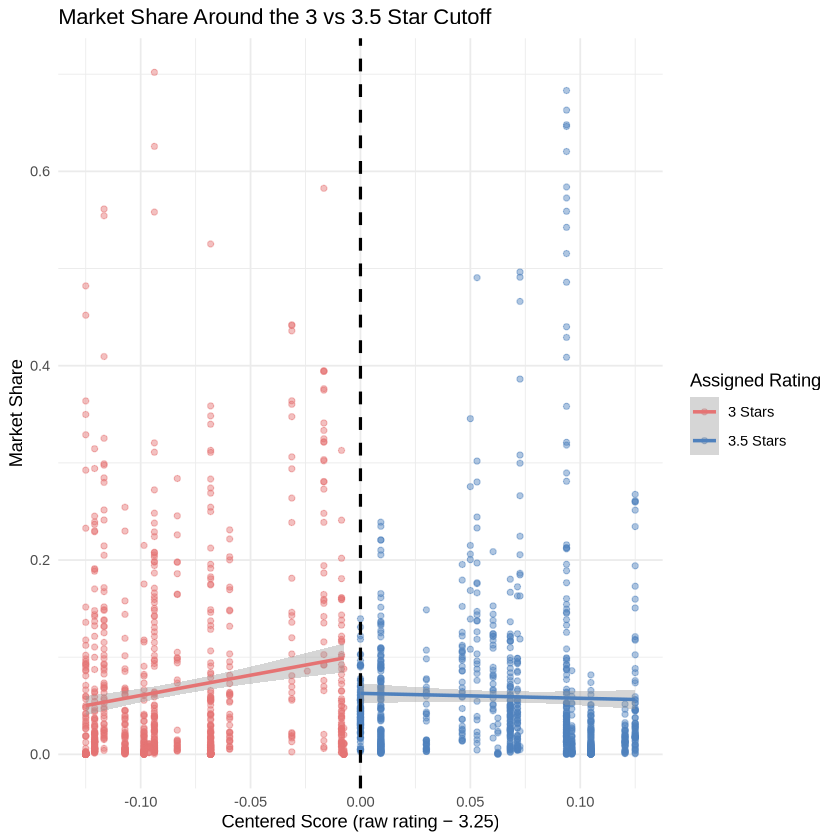

In [25]:
plans_3.5 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

band_3.5 <- plans_3.5 %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating < 3.25  & Star_Rating == 3) |
    (raw_rating >= 3.25 & Star_Rating == 3.5)
  )

rd_3.5 <- band_3.5 %>%
  mutate(
    score = raw_rating - 3.25,          
    treat_group = score >= 0,      
    in_window = between(score, -0.125, 0.125),
    interaction = score * treat_group
  )

p_3.5 <- ggplot(rd_3.5 %>% filter(in_window), 
             aes(x = score, y = mkt_share, color = treat_group)) +
  geom_point(alpha = 0.45, size = 1.4) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 0.9) +
  scale_color_manual(
    values = c("FALSE" = "#E57373", "TRUE" = "#4F81BD"),
    labels = c("3 Stars", "3.5 Stars")
  ) +
  labs(
    title = "Market Share Around the 3 vs 3.5 Star Cutoff",
    x = "Centered Score (raw rating − 3.25)",
    y = "Market Share",
    color = "Assigned Rating"
  ) +
  theme_minimal()

p_3.5


# Problem 9

For the plans around the 2.75 cutoff, the HMO share jumps dramatically from 2.9% below to 37.5% above the cutoff, and Part D participation rises from 55.8% to 80.9%. This stark difference suggests that the plans above and below are not comparable as they do not look similar. For RD variability, we would want the plans to look similar for an ideal comparison. At the 3.25 cutoff, the HMO share percentage is quite different but the Part D participation is nearly identical, showing that the plans above and below are similar to one another. 

In [26]:
near_275 <- datanew.2010 %>%
  mutate(
    score = raw_rating - 2.75,
    group = ifelse(score >= 0, "Above cutoff", "Below cutoff")
  ) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes"
  ) %>%
  group_by(group) %>%
  summarise(
    share_HMO = mean(HMO),
    share_PartD = mean(PartD),
    n = n()
  )

cat("Table: Plan Characteristics Around the 2.75 Cutoff\n")
print(near_275)


Table: Plan Characteristics Around the 2.75 Cutoff
# A tibble: 2 × 4
  group        share_HMO share_PartD     n
  <chr>            <dbl>       <dbl> <int>
1 Above cutoff    0.375        0.809   858
2 Below cutoff    0.0291       0.558  5094


In [27]:
near_325 <- datanew.2010 %>%
  mutate(
    score = raw_rating - 3.25,
    group = ifelse(score >= 0, "Above cutoff", "Below cutoff")) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes") %>%
 
group_by(group) %>%
  summarise(
    share_HMO = mean(HMO),
    share_PartD = mean(PartD),
    n = n()
  )

cat("Table: Plan Characteristics Around the 3.25 Cutoff (3–3.5 Stars)\n")
print(near_325)


Table: Plan Characteristics Around the 3.25 Cutoff (3–3.5 Stars)
# A tibble: 2 × 4
  group        share_HMO share_PartD     n
  <chr>            <dbl>       <dbl> <int>
1 Above cutoff     0.380       0.848  1003
2 Below cutoff     0.609       0.845  1164


In [28]:
knitr::kable(
  near_275,
  caption  = "Plan Characteristics Around the 2.75 Cutoff (2.5-3 Stars)",
  col.names = c("Group", "Share HMO", "Share PartD", "N"),
  align    = c("l", "c", "c", "c"),
  booktabs = TRUE
)
    
knitr::kable(
  near_325,
  caption  = "Plan Characteristics Around the 3.25 Cutoff (3-3.5 Stars)",
  col.names = c("Group", "Share HMO", "Share PartD", "N"),
  align    = c("l", "c", "c", "c"),
  booktabs = TRUE
)



Table: Plan Characteristics Around the 2.75 Cutoff (2.5-3 Stars)

|Group        | Share HMO | Share PartD |  N   |
|:------------|:---------:|:-----------:|:----:|
|Above cutoff | 0.3752914 |  0.8088578  | 858  |
|Below cutoff | 0.0290538 |  0.5577150  | 5094 |



Table: Plan Characteristics Around the 3.25 Cutoff (3-3.5 Stars)

|Group        | Share HMO | Share PartD |  N   |
|:------------|:---------:|:-----------:|:----:|
|Above cutoff | 0.3798604 |  0.8484546  | 1003 |
|Below cutoff | 0.6091065 |  0.8445017  | 1164 |

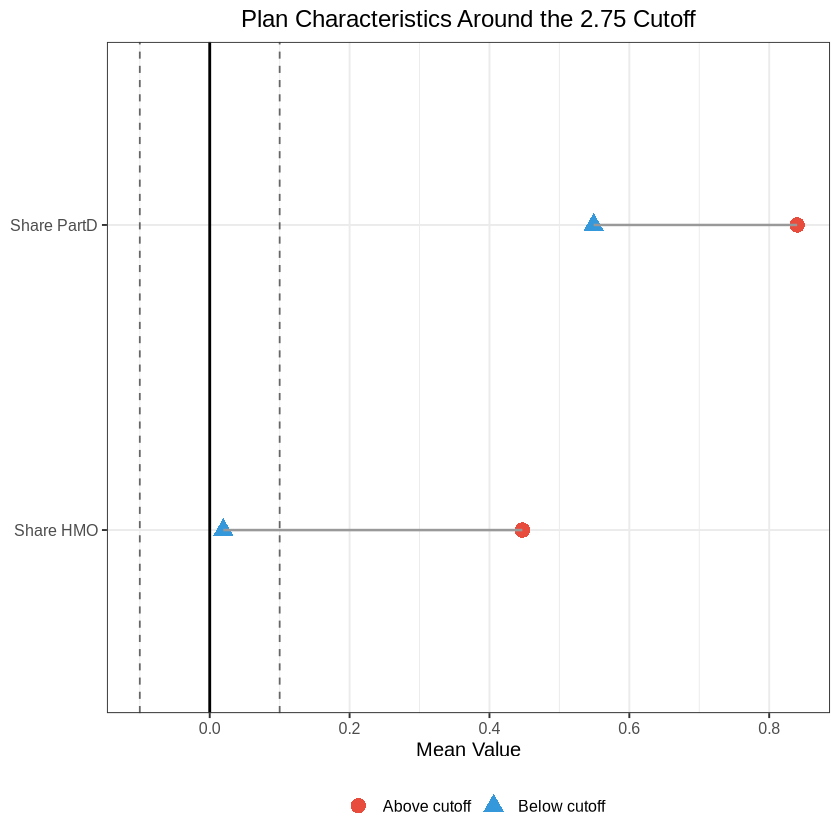

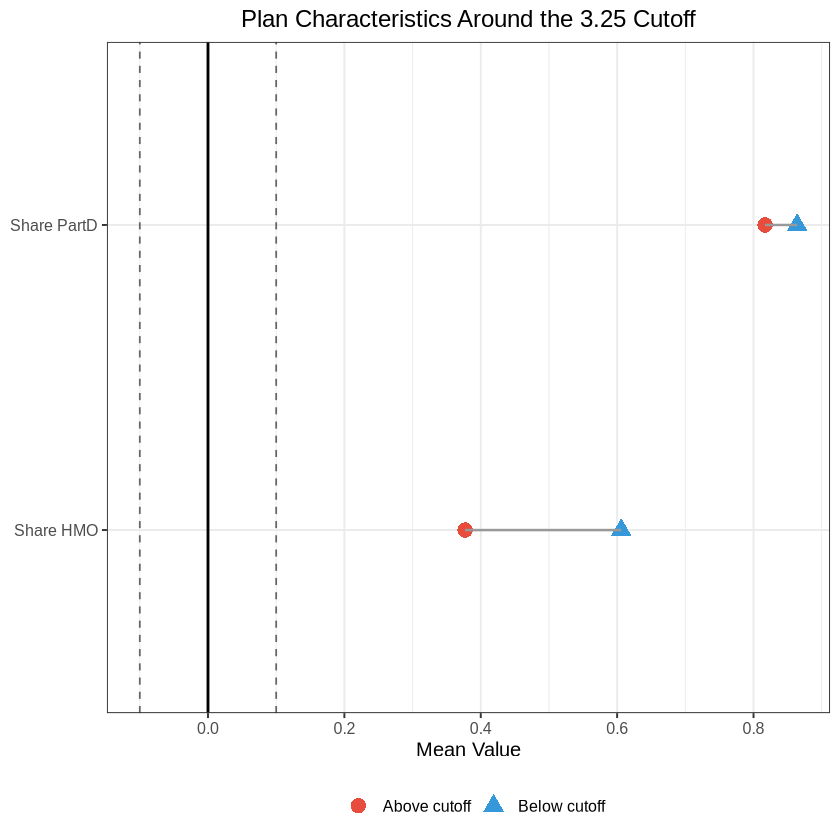

In [29]:
library(tidyverse)

love_data_275 <- tibble(
  variable = rep(c("Share HMO", "Share PartD"), each = 2),
  group = rep(c("Above cutoff", "Below cutoff"), 2),
  value = c(0.447, 0.0194, 0.840, 0.549)
)

love_data_325 <- tibble(
  variable = rep(c("Share HMO", "Share PartD"), each = 2),
  group = rep(c("Above cutoff", "Below cutoff"), 2),
  value = c(0.377, 0.606, 0.817, 0.864)
)

love_plot <- function(data, title) {
  ggplot(data, aes(x = value, y = variable, color = group, shape = group)) +
    geom_point(size = 4) +
    geom_line(aes(group = variable), color = "gray60", linewidth = 0.7) +
    geom_vline(xintercept = 0, linewidth = 0.8) +
    geom_vline(xintercept = c(-0.1, 0.1), linetype = "dashed", color = "gray40") +
    scale_color_manual(values = c("Above cutoff" = "#E74C3C", "Below cutoff" = "#3498DB")) +
    labs(
      title = title,
      x = "Mean Value",
      y = NULL,
      color = NULL,
      shape = NULL
    ) +
    theme_bw(base_size = 12) +
    theme(
      legend.position = "bottom",
      plot.title = element_text(hjust = 0.5)
    )
}

p1 <- love_plot(love_data_275, "Plan Characteristics Around the 2.75 Cutoff")
p2 <- love_plot(love_data_325, "Plan Characteristics Around the 3.25 Cutoff")

p1
p2

# Problem 10 

Overall, plans with higher star star ratings tend to have more people enrolled in them, and this pattern holds across all years from 2010-2015. The biggest jump happens at the 2.75 cutoff because when a plan goes from 2.5 to 3 stars, it gets significantly more enrollments while the jump from 4 to 3.5 stars matter less. However, the results need to be approached with caution. First, plans are not random near the cutoff, especially around the 2.75 threshold as the slope shows a sharp increase of plans right above the threshold. Also, plans above the threshold look quite different from those below when comparing if they are HMO and/or have plan D. In conclusion, star ratings seem to matter for enrollment but we cannot quantify the direct amount of how much they matter. 